# 🔍 Notebook 09: Giải Phẫu Mô Hình với SHAP (Global & Local Explainability)

> **Mục tiêu**: Mô hình Machine Learning trong Ngân hàng không thể là một "hộp đen". Chúng ta sử dụng SHAP (SHapley Additive exPlanations) cho cả 2 cấp độ:
> 1. **Global Explainability**: Toàn bộ mô hình học được gì? Top đặc trưng nào quyết định rủi ro gian lận?
> 2. **Local Explainability (Waterfall Plot)**: **Từng giao dịch cụ thể** tại sao bị gắn cờ? (Giải thích cho nhân viên Compliance & Fraud Analyst).


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_processed_data, load_raw_data, temporal_split
from src.explainability import (
    calculate_shap_values, 
    plot_shap_summary, 
    plot_shap_dependence,
    plot_shap_waterfall,
    get_top_influential_features
)

print("Loading Data and Model...")
df_test = load_processed_data("test.parquet")
X_test = df_test.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_test = df_test['fraud_bool'].values

estimator = xgb.XGBClassifier()
estimator.load_model(str(PROJECT_ROOT / "models" / "xgboost_best.json"))

# Tính SHAP Values trên 2,000 mẫu đại diện
print("Calculating SHAP values...")
base_value, shap_values, X_sample = calculate_shap_values(estimator, X_test, max_samples=2000)
y_sample = y_test[X_sample.index]

# Dự đoán xác suất rủi ro trên tập mẫu
OPTIMAL_THRESHOLD = 0.48
probs_sample = estimator.predict_proba(X_sample)[:, 1]
preds_sample = (probs_sample >= OPTIMAL_THRESHOLD).astype(int)

print(f"Base Value (log-odds prior): {base_value:.4f}")
print(f"X_sample shape: {X_sample.shape}")


Loading Data and Model...
Calculating SHAP values...
Base Value (log-odds prior): 0.1009
X_sample shape: (2000, 33)


## 1. Global Explainability: Toàn Cảnh Các Đặc Trưng Quan Trọng
Summary Plot (Dot Plot) biểu thị phân phối đóng góp của từng đặc trưng lên toàn bộ tập dữ liệu:
- **Trục Y**: Sắp xếp từ đặc trưng quan trọng nhất xuống dưới.
- **Trục X (SHAP value)**: Điểm dương (`> 0`) làm tăng nguy cơ Fraud, điểm âm (`< 0`) bảo vệ giao dịch là hợp lệ.
- **Màu sắc**: Giá trị thực của feature (Đỏ = Giá trị cao, Xanh = Giá trị thấp).


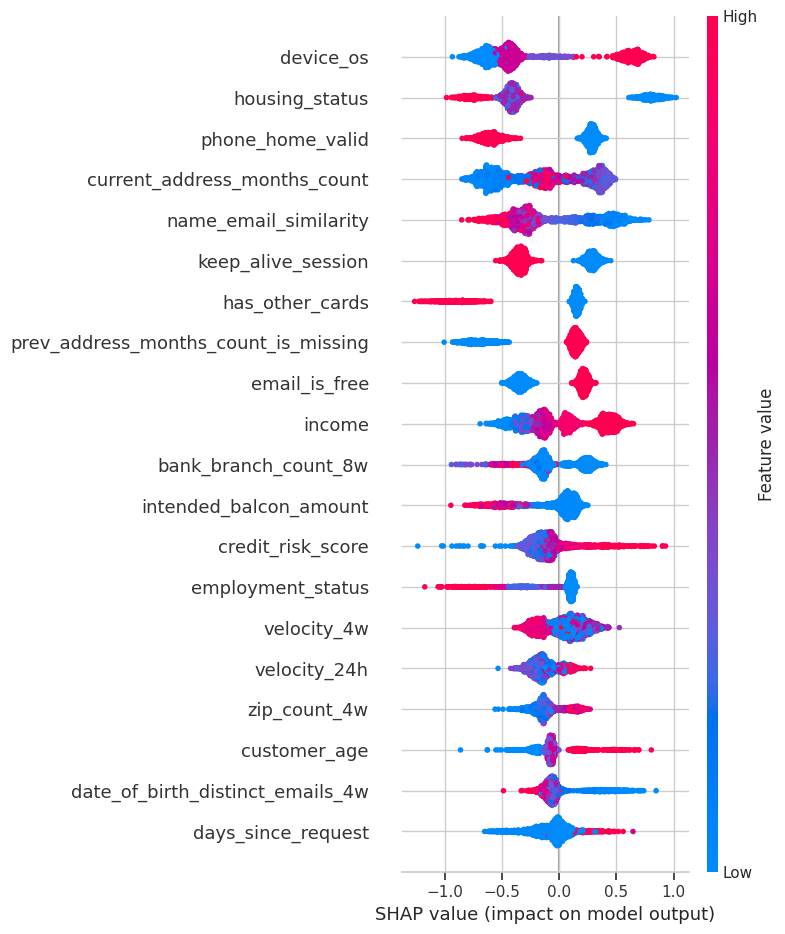

In [2]:
plot_shap_summary(shap_values, X_sample, plot_type="dot")


## 2. Phân Tích Tương Tác & Nguyên Nhân Thiên Vị (Age Dependence Plot)
Kiểm tra xem `customer_age` tương tác với đặc trưng nào (ví dụ `income`, `housing_status`) để đẩy điểm rủi ro lên cao.


<Figure size 800x600 with 0 Axes>

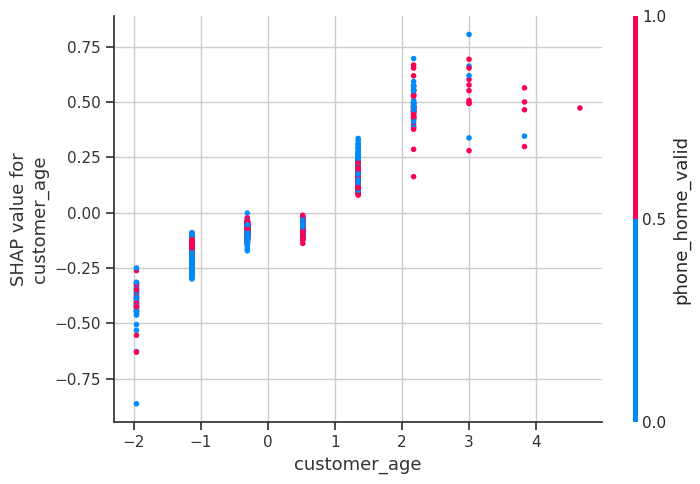

In [3]:
plot_shap_dependence("customer_age", shap_values, X_sample)


## 3. Local Explainability: Giải Thích Từng Giao Dịch Cụ Thể (Waterfall Plot)
Trong thực tế vận hành tại Ngân hàng, Compliance Team cần biết: **"Tại sao case này bị chặn?"**

Ta sẽ trích xuất và giải thích 3 trường hợp điển hình:
1. **True Positive (TP)**: Bắt đúng 1 vụ gian lận tinh vi.
2. **False Positive (FP)**: Bắt oan 1 khách hàng hợp pháp (để hỗ trợ gỡ phong tỏa tài khoản).
3. **True Negative (TN)**: Giao dịch bình thường, an toàn.


In [4]:
# Tìm index của các ca tiêu biểu trong X_sample
tp_indices = np.where((preds_sample == 1) & (y_sample == 1))[0]
fp_indices = np.where((preds_sample == 1) & (y_sample == 0))[0]
tn_indices = np.where((preds_sample == 0) & (y_sample == 0))[0]

tp_idx = tp_indices[0] if len(tp_indices) > 0 else 0
fp_idx = fp_indices[0] if len(fp_indices) > 0 else 1
tn_idx = tn_indices[0] if len(tn_indices) > 0 else 2

print(f"Case TP (Bắt đúng fraud): Index {tp_idx}, Prob = {probs_sample[tp_idx]:.4f}")
print(f"Case FP (Bắt oan hợp pháp): Index {fp_idx}, Prob = {probs_sample[fp_idx]:.4f}")
print(f"Case TN (Giao dịch an toàn): Index {tn_idx}, Prob = {probs_sample[tn_idx]:.4f}")


Case TP (Bắt đúng fraud): Index 28, Prob = 0.9811
Case FP (Bắt oan hợp pháp): Index 0, Prob = 0.7030
Case TN (Giao dịch an toàn): Index 1, Prob = 0.0903


### 3.1 Case 1: True Positive (Phát hiện gian lận thật)


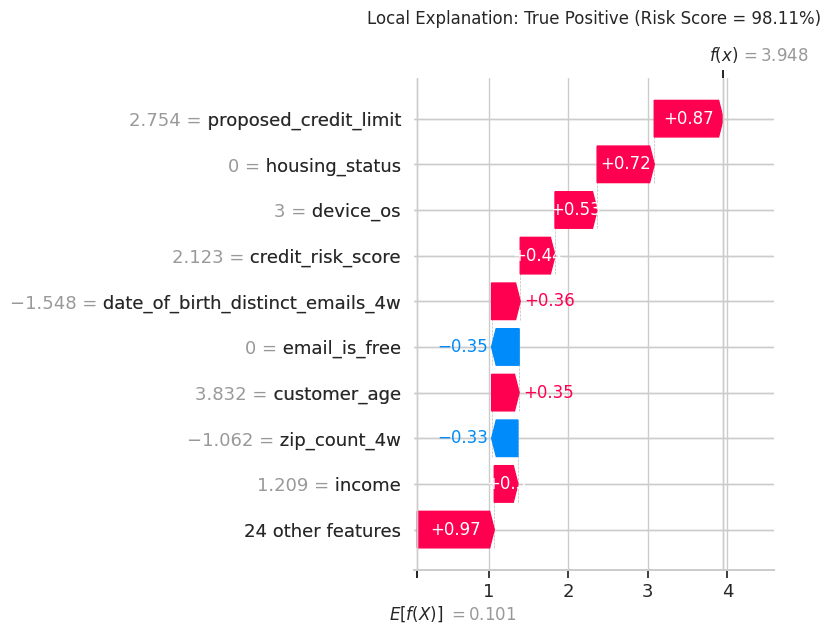

In [5]:
plot_shap_waterfall(
    shap_values=shap_values,
    X_sample=X_sample,
    row_idx=tp_idx,
    base_value=base_value,
    max_display=10,
    title=f"Local Explanation: True Positive (Risk Score = {probs_sample[tp_idx]:.2%})"
)


### 3.2 Case 2: False Positive (Phân tích nguyên nhân Bắt Oan)


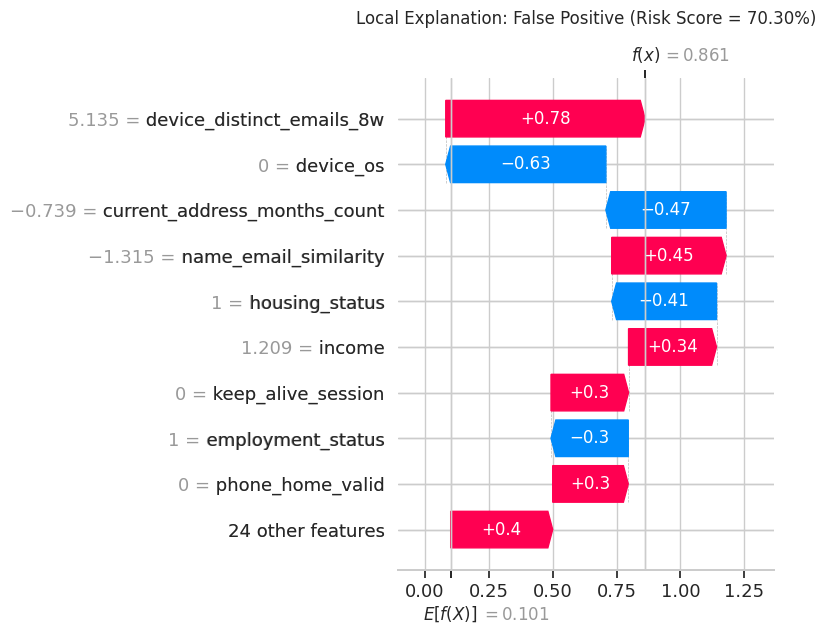

In [6]:
plot_shap_waterfall(
    shap_values=shap_values,
    X_sample=X_sample,
    row_idx=fp_idx,
    base_value=base_value,
    max_display=10,
    title=f"Local Explanation: False Positive (Risk Score = {probs_sample[fp_idx]:.2%})"
)


## 4. Trích Xuất Dữ Liệu Cấu Trúc Để Đưa Vào LLM Explanation Layer
Hàm `get_top_influential_features` chuyển đổi SHAP values thành định dạng JSON/Dictionary có cấu trúc để chuyển tiếp sang **Notebook 10 (LLM Translation)** và **FastAPI Response**.


In [7]:
top_reasons_tp = get_top_influential_features(
    shap_values_row=shap_values[tp_idx],
    feature_names=list(X_sample.columns),
    feature_values_row=X_sample.iloc[tp_idx].values,
    top_k=5
)

print("Top 5 yếu tố quyết định của Case True Positive:")
df_reasons = pd.DataFrame(top_reasons_tp)
display(df_reasons[['feature', 'value', 'shap_value', 'impact']])


Top 5 yếu tố quyết định của Case True Positive:


,feature,value,shap_value,impact
0,proposed_credit_limit,2.754397,0.867135,TĂNG RỦI RO (Fraud)
1,housing_status,0.000000,0.718211,TĂNG RỦI RO (Fraud)
2,device_os,3.000000,0.529838,TĂNG RỦI RO (Fraud)
3,credit_risk_score,2.123013,0.437517,TĂNG RỦI RO (Fraud)
4,date_of_birth_distinct_emails_4w,-1.547921,0.360337,TĂNG RỦI RO (Fraud)


👉 **Bước tiếp theo (Notebook 10)**: 
Chúng ta sẽ lấy bảng Top 5 lý do này làm đầu vào (Input Context) cho mô hình ngôn ngữ (LLM) để dịch tự động sang một đoạn văn bản tiếng Việt tự nhiên, sẵn sàng gửi cho bộ phận Chăm sóc khách hàng hoặc Điều tra gian lận!
